## Строим и интерпретируем кластеризации

### Окружение

Датасет: [German Credit](https://www.kaggle.com/uciml/german-credit) — 1000 заёмщиков немецкого банка. Задача: кластеризация.

In [1]:
%pip install -q numpy pandas scikit-learn scipy matplotlib seaborn umap-learn


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Загрузка данных

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

# Зеркало на GitHub: качается без Kaggle-токена, поэтому ноутбук воспроизводим.
URL = "https://raw.githubusercontent.com/ziadasal/Credit-Risk-Assessment/main/german_credit_data.csv"

# Путь относительный: рабочая директория ядра — папка с ноутбуком.
DATA_PATH = Path("data") / "german_credit_data.csv"

if DATA_PATH.exists():
    print(f"Файл уже на месте: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024:.0f} КБ)")
else:
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(URL, DATA_PATH)
    print(f"Скачано: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024:.0f} КБ)")

Файл уже на месте: data/german_credit_data.csv (52 КБ)


## EDA

### Первичный осмотр

In [3]:
import pandas as pd

# Первая колонка в файле безымянная и содержит номер строки. Без index_col=0
# она попала бы в признаки как порядковый номер клиента.
df = pd.read_csv(DATA_PATH, index_col=0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [5]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [6]:
# describe() по умолчанию берёт только числовые колонки — здесь это 4 из 10.
# .T — так шесть строковых колонок читаются в столбик.
df.describe(include="str").T

,count,unique,top,freq
Sex,1000,2,male,690
Housing,1000,3,own,713
Saving accounts,817,4,little,603
Checking account,606,3,little,274
Purpose,1000,8,car,337
Risk,1000,2,good,700


Видно сразу: 1000 строк, 9 признаков и метка `Risk`. Пропуски есть только в двух колонках — `Saving accounts` (817 из 1000) и `Checking account` (606 из 1000).

### Шаг 1. Пропуски в счетах

Смотрим, случайны ли пропуски. Если строки с пропуском ничем не отличаются от остальных — можно заполнить. Если отличаются — пропуск сам по себе что-то значит.

In [7]:
ACCOUNT_COLS = ["Saving accounts", "Checking account"]

for c in ACCOUNT_COLS:
    print(f"{c:18}: {df[c].isna().sum():4d} пропусков ({df[c].isna().mean():.1%})")

sav_na, chk_na = df["Saving accounts"].isna(), df["Checking account"].isna()
print()
print(f"нет обоих счетов   : {(sav_na & chk_na).sum():4d}")
print(f"нет хотя бы одного : {(sav_na | chk_na).sum():4d}")
print(f"есть оба           : {(~sav_na & ~chk_na).sum():4d}")

Saving accounts   :  183 пропусков (18.3%)
Checking account  :  394 пропусков (39.4%)

нет обоих счетов   :   99
нет хотя бы одного :  478
есть оба           :  522


In [8]:
# Сравниваем медианы: при случайном пропуске они должны совпасть.
print(f"{'колонка':18} {'группа':10} {'n':>5} {'Credit amount':>14} {'Duration':>9} {'Age':>6}")
for c in ACCOUNT_COLS:
    m = df[c].isna()
    for label, mask in [("пропуск", m), ("заполнено", ~m)]:
        print(f"{c if label == 'пропуск' else '':18} {label:10} {mask.sum():5d} "
              f"{df.loc[mask, 'Credit amount'].median():14.0f} "
              f"{df.loc[mask, 'Duration'].median():9.0f} {df.loc[mask, 'Age'].median():6.0f}")

колонка            группа         n  Credit amount  Duration    Age
Saving accounts    пропуск      183           2859        21     36
                   заполнено    817           2241        18     32
Checking account   пропуск      394           2248        18     34
                   заполнено    606           2342        18     32


Медианы не совпадают: без сберегательного счёта заём крупнее (2859 против 2241), клиент старше (36 против 32). Пропуск не случаен.

В описании датасета UCI эти значения означают "нет такого счёта", а не "неизвестно". То есть это нормальное значение признака, просто записано пустой ячейкой. Удалять такие строки нельзя — их 478 из 1000.

### Шаг 2. Дубликаты строк

Признаков мало и уровней у них мало, поэтому одинаковые строки вполне возможны. Для кластеризации они вредны: копии одной точки создают сгущение, которое алгоритм примет за кластер.

In [9]:
FEATURES = [c for c in df.columns if c != "Risk"]

# Отдельно проверяем повторы без метки: так найдутся пары, различающиеся только Risk.
groups = df.groupby(FEATURES, dropna=False).agg(n=("Risk", "size"), risk_uniq=("Risk", "nunique"))
twins = groups[groups["n"] > 1]

print(f"полных повторов по всем 10 колонкам : {df.duplicated().sum():4d}")
print(f"повторов по 9 признакам без Risk    : {df.duplicated(subset=FEATURES).sum():4d}")
print(f"групп-близнецов                     : {len(twins):4d}")
print(f"из них с разной меткой              : {(twins['risk_uniq'] > 1).sum():4d}")

полных повторов по всем 10 колонкам :    0
повторов по 9 признакам без Risk    :    0
групп-близнецов                     :    0
из них с разной меткой              :    0


Повторов нет

### Шаг 3. Типы признаков

In [10]:
QUANT = ["Age", "Credit amount", "Duration"]
ORDINAL = ["Job", "Saving accounts", "Checking account"]
NOMINAL = ["Sex", "Housing", "Purpose"]
TYPE_OF = {**dict.fromkeys(QUANT, "количественный"),
           **dict.fromkeys(ORDINAL, "порядковый"),
           **dict.fromkeys(NOMINAL, "категориальный")}

print(f"{'признак':18} {'тип':16} {'уровней':>8}  значения")
for c in FEATURES:
    vals = sorted(df[c].dropna().unique().tolist())
    shown = ", ".join(map(str, vals)) if len(vals) <= 8 else f"{len(vals)} различных чисел"
    print(f"{c:18} {TYPE_OF[c]:16} {df[c].nunique():8d}  {shown}")

признак            тип               уровней  значения
Age                количественный         53  53 различных чисел
Sex                категориальный          2  female, male
Job                порядковый              4  0, 1, 2, 3
Housing            категориальный          3  free, own, rent
Saving accounts    порядковый              4  little, moderate, quite rich, rich
Checking account   порядковый              3  little, moderate, rich
Credit amount      количественный        921  921 различных чисел
Duration           количественный         33  33 различных чисел
Purpose            категориальный          8  business, car, domestic appliances, education, furniture/equipment, radio/TV, repairs, vacation/others


Получилось три группы по три признака.

- **Количественные** — уже числа, кодировать нечего.
- **Порядковые** — уровни упорядочены (`little` < `moderate` < `rich`, неквалифицированный < квалифицированный). Нужен номер уровня. One-hot сломал бы порядок: `little` оказался бы одинаково далёк от `moderate` и от `rich`.
- **Категориальные** — порядка нет. Нужен one-hot. Номера 0, 1, 2 создали бы порядок, которого нет: `car` оказался бы ближе к `education`, чем к `radio/TV`.

### Шаг 4. Распределения количественных признаков

Смотрим форму. Для KMEANS важен длинный хвост: центр кластера считается как среднее, а среднее к хвосту чувствительно.

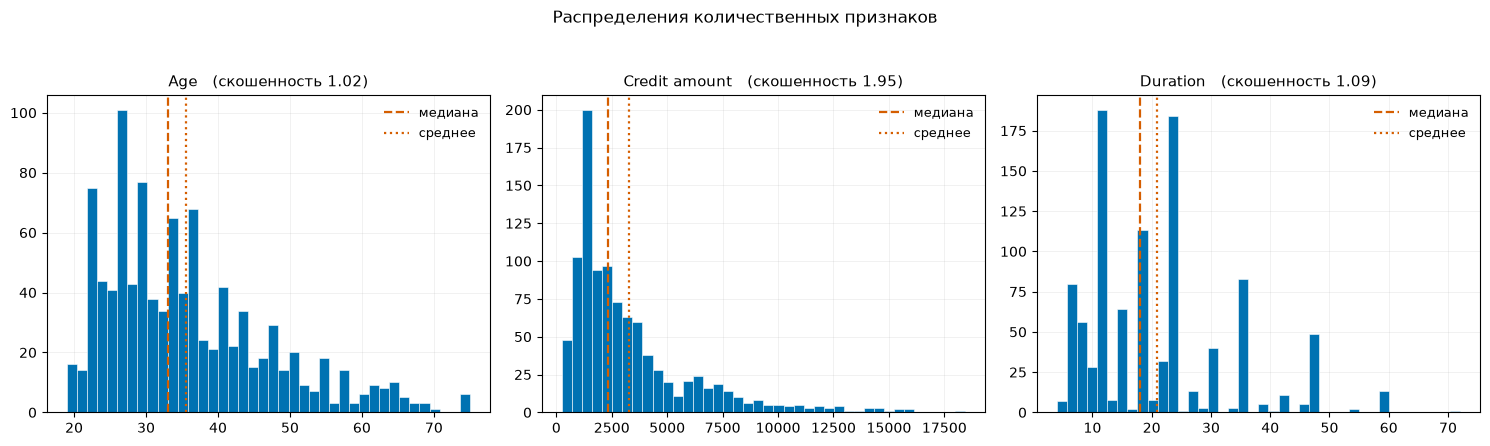

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# Цвета Okabe-Ito: различимы при дальтонизме и в чёрно-белой печати.
COLOR_MAIN = "#0072B2"
COLOR_REF = "#D55E00"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, QUANT):
    ax.hist(df[c], bins=40, color=COLOR_MAIN, edgecolor="white", linewidth=0.4)
    ax.axvline(df[c].median(), color=COLOR_REF, linestyle="--", linewidth=1.6, label="медиана")
    ax.axvline(df[c].mean(), color=COLOR_REF, linestyle=":", linewidth=1.6, label="среднее")
    ax.set_title(f"{c}   (скошенность {skew(df[c]):.2f})", fontsize=11)
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Распределения количественных признаков", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [12]:
# Расхождение среднего и медианы — самый прямой признак хвоста.
print(f"{'признак':16} {'медиана':>9} {'среднее':>9} {'скошенн.':>9} {'макс. z':>8} {'|z| > 3':>8}")
for c in QUANT:
    s = df[c]
    z = (s - s.mean()) / s.std()
    print(f"{c:16} {s.median():9.1f} {s.mean():9.1f} {skew(s):9.2f} {z.max():8.2f} {(z.abs() > 3).sum():8d}")

признак            медиана   среднее  скошенн.  макс. z  |z| > 3
Age                   33.0      35.5      1.02     3.47        7
Credit amount       2319.5    3271.3      1.95     5.37       25
Duration              18.0      20.9      1.09     4.24       14


У `Credit amount` хвост заметный: скошенность 1,95, среднее 3271 против медианы 2320, 25 клиентов дальше трёх сигм, максимум — 5,4 сигмы. У `Age` и `Duration` скошенность около 1,0 — обычная асимметрия.

`Credit amount` надо логарифмировать. Масштабирование тут не поможет — оно сжимает шкалу целиком, а форму не меняет.

### Шаг 5. Корреляция количественных признаков

Расстояние складывает вклады всех признаков. Если два признака дублируют друг друга, общий фактор входит в сумму дважды.

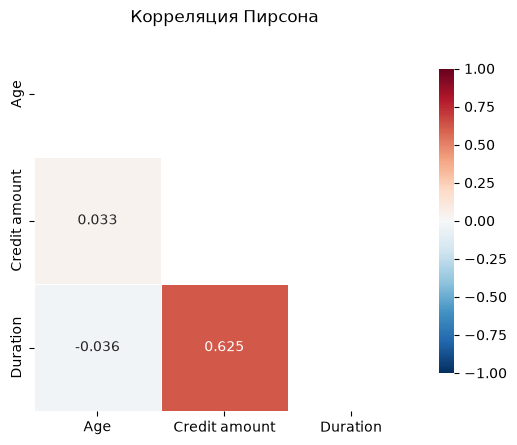

Пирсон,  Credit amount ~ Duration : 0.6250
Спирмен, Credit amount ~ Duration : 0.6247
Пирсон,  Age ~ Credit amount      : 0.0327
Пирсон,  Age ~ Duration           : -0.0361


In [13]:
import seaborn as sns

corr = df[QUANT].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
# Прячем диагональ и верх: единицы на диагонали смысла не несут, но красятся ярче всего.
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Корреляция Пирсона", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Пирсон,  Credit amount ~ Duration : {corr.loc['Credit amount', 'Duration']:.4f}")
print(f"Спирмен, Credit amount ~ Duration : {df[QUANT].corr(method='spearman').loc['Credit amount', 'Duration']:.4f}")
print(f"Пирсон,  Age ~ Credit amount      : {corr.loc['Age', 'Credit amount']:.4f}")
print(f"Пирсон,  Age ~ Duration           : {corr.loc['Age', 'Duration']:.4f}")

`Credit amount` и `Duration` связаны на 0,625 — крупные займы берут на больший срок. Разные методики дают одинаковые результаты, значит связь настоящая, а не наведена хвостом. Общего у них около 39% дисперсии (0.625^2), своего у каждого около 61% — это разные признаки, объединять их не будем.

`Age` не связан ни с чем (0,03 и −0,04).

### Шаг 6. Кардинальность и редкие категории

Считаем, сколько клиентов в каждом уровне.

У категориальных признаков каждый уровень станет отдельной колонкой. Уровень из 12 человек получит такую же колонку, как уровень из 300, и в расстоянии будет весить столько же. Поэтому редкие уровни схлопываем.

У порядковых признаков отдельных колонок не будет — там смотрим на другое: сколько пропусков и насколько заполнена шкала.

In [14]:
CAT_COLS = ORDINAL + NOMINAL

for c in CAT_COLS:
    print(f"--- {c} ({df[c].nunique()} уровней) ---")
    for level, n in df[c].value_counts(dropna=False).items():
        mark = "  <- редкий" if n / len(df) < 0.05 else ""
        print(f"    {str(level):24} {n:5d}  {n / len(df):6.1%}{mark}")
    print()

--- Job (4 уровней) ---
    2                          630   63.0%
    1                          200   20.0%
    3                          148   14.8%
    0                           22    2.2%  <- редкий

--- Saving accounts (4 уровней) ---
    little                     603   60.3%
    nan                        183   18.3%
    moderate                   103   10.3%
    quite rich                  63    6.3%
    rich                        48    4.8%  <- редкий

--- Checking account (3 уровней) ---
    nan                        394   39.4%
    little                     274   27.4%
    moderate                   269   26.9%
    rich                        63    6.3%

--- Sex (2 уровней) ---
    male                       690   69.0%
    female                     310   31.0%

--- Housing (3 уровней) ---
    own                        713   71.3%
    rent                       179   17.9%
    free                       108   10.8%

--- Purpose (8 уровней) ---
    car               

У `Purpose` три уровня из восьми не дотягивают до 5%: `repairs` (22), `domestic appliances` (12), `vacation/others` (12) — вместе 46 клиентов. Схлопнем их в один.

Порог отметил ещё два уровня у порядковых признаков — `rich` в `Saving accounts` (48 клиентов, 4,8%) и `Job = 0` (22 клиента, 2,2%). Их трогать не будем: порядковый признак становится одним числом, а не набором колонок, отдельной оси у редкого уровня не появляется. Проблема редких уровней возникает только при one-hot.

Про 22 клиента с `Job = 0`: наблюдений мало, и опираться на этот уровень при разборе кластеров нельзя.

### Шаг 7. Разброс масштабов

Смотрим, в каких единицах измерены количественные признаки. Это понадобится в разделе про масштабирование.

In [15]:
# Только количественные: у них есть настоящие единицы — годы, марки, месяцы.
# Шкала порядкового признака (0…3 у Job) — это наша нумерация уровней, её размах
# сравнивать с размахом в марках нечего.
print(f"{'признак':16} {'min':>8} {'max':>8} {'размах':>9} {'std':>10}")
for c in QUANT:
    s = df[c]
    print(f"{c:16} {s.min():8.0f} {s.max():8.0f} {s.max() - s.min():9.0f} {s.std():10.2f}")

stds = df[QUANT].std()
print()
print(f"отношение наибольшего std к наименьшему  : {stds.max() / stds.min():10.1f}")
print(f"то же в квадратах (так входит в расстояние) : {(stds.max() / stds.min()) ** 2:10.0f}")

признак               min      max    размах        std
Age                    19       75        56      11.38
Credit amount         250    18424     18174    2822.74
Duration                4       72        68      12.06

отношение наибольшего std к наименьшему  :      248.1
то же в квадратах (так входит в расстояние) :      61575


`Credit amount` измерен в марках, размах 18174. `Age` — в годах, размах 56. Стандартные отклонения различаются в 248 раз. Евклидово расстояние складывает квадраты, поэтому в расстояние разница входит как 61 575 раз.

Сколько это стоит на практике — посчитаем отдельно.

### Шаг 8. Метка `Risk`

`Risk` — это результат займа, а не свойство клиента. В матрицу признаков она не идёт: кластеризация должна найти группы сама. Держим её отдельно, чтобы потом проверить, осмысленны ли кластеры.

Заодно смотрим долю проблемных займов по уровням счетов — надо решить, куда на шкале ставить "нет счёта".

In [16]:
print("распределение метки:")
for level, n in df["Risk"].value_counts().items():
    print(f"    {level:6} {n:5d}  {n / len(df):6.1%}")
print()

# Пропуск временно показываем как обычный уровень, чтобы увидеть его место на шкале.
for c, order in [("Saving accounts", ["little", "moderate", "quite rich", "rich"]),
                 ("Checking account", ["little", "moderate", "rich"])]:
    shown = df[c].fillna("нет счёта")
    print(f"--- доля проблемных займов, {c} ---")
    for level in ["нет счёта"] + order:
        m = shown == level
        print(f"    {level:12} n = {m.sum():4d}   bad = {(df.loc[m, 'Risk'] == 'bad').mean():.1%}")
    print()

распределение метки:
    good     700   70.0%
    bad      300   30.0%

--- доля проблемных займов, Saving accounts ---
    нет счёта    n =  183   bad = 17.5%
    little       n =  603   bad = 36.0%
    moderate     n =  103   bad = 33.0%
    quite rich   n =   63   bad = 17.5%
    rich         n =   48   bad = 12.5%

--- доля проблемных займов, Checking account ---
    нет счёта    n =  394   bad = 11.7%
    little       n =  274   bad = 49.3%
    moderate     n =  269   bad = 39.0%
    rich         n =   63   bad = 22.2%



Неожиданный результат. Казалось бы, "нет счёта" — это низ шкалы: нет денег, значит риск выше. На деле наоборот.

У `Checking account` клиенты без счёта дают 11,7% проблемных займов — лучше всех, даже лучше `rich` (22,2%). У `Saving accounts` — 17,5%, столько же, сколько у `quite rich`. Объяснение простое: расчётный счёт с овердрафтом нужен тому, кому не хватает до зарплаты.

Значит, поставить "нет счёта" в ноль шкалы было бы ошибкой. Но и опереться на эти числа при кодировании нельзя — они посчитаны по метке, а метка в признаках участвовать не должна. Метка показала только одно: наша догадка была бы неверной, а правильного места мы не знаем.

### Найденные несостыковки

Размер: **1000 строк × 10 колонок** (9 признаков + метка `Risk`).

**1. Пропуски есть в двух колонках, и это не пропуски.**
`Saving accounts` — 183 (18,3%), `Checking account` — 394 (39,4%). Клиенты с пропуском отличаются от остальных: заём крупнее, возраст выше. По описанию UCI это отдельная категория "нет такого счёта". Заполнять средним или удалять строки нельзя.

**2. "Нет счёта" — не низ шкалы.**
Доля проблемных займов у клиентов без расчётного счёта 11,7% против 49,3% у `little` и 22,2% у `rich`. Куда именно ставить этот уровень — неизвестно, а очевидный вариант (ноль) заведомо неверен.

**3. Дубликатов нет.**
Ни одного повтора, ни противоречивой разметки. Для кластеризации это важно: копии точек дали бы ложные сгущения.

**4. Признаки трёх разных типов, по три штуки каждого.**
Количественные, порядковые и категориальные. Одним методом их не закодировать: one-hot сломает порядок у порядковых, а номера придумают порядок у категориальных.

**5. У `Credit amount` тяжёлый хвост.**
Скошенность 1,95. Центроид KMEANS уедет к крупным займам. Масштабирование от этого не спасает — нужен логарифм.

**6. `Credit amount` и `Duration` связаны на 0,625.**
Не настолько, чтобы считать их одним признаком (своей дисперсии у каждого 61%), но достаточно, чтобы фактор "размер займа" весил больше остальных.

**7. У `Purpose` три редких уровня из восьми** — вместе 46 клиентов, 4,6%.

**8. Масштабы количественных признаков различаются на два порядка.**
`Credit amount` в марках против `Age` в годах: отношение стандартных отклонений 248, в квадратах 61 575.

**9. Метка: 700 хороших займов и 300 проблемных.** В обучении не участвует, пригодится как ориентир при проверке кластеров.

Что делаем дальше:

- пропуски в счетах — отдельным уровнем;
- шкалу счёта и факт его отсутствия — в разные колонки, раз место на шкале неизвестно;
- кодируем каждый признак по его типу;
- `Credit amount` логарифмируем;
- редкие уровни `Purpose` схлопываем;
- масштабируем и показываем цифрами, что было бы без этого.

#### Рабочая гипотеза (сформулирована до экспериментов)

Кластеры возникают там, где признаки согласованы: группа отличается сразу по нескольким осям. Здесь такого не видно. Единственная заметная связь во всём датасете — 0,625 между суммой и сроком займа, то есть один фактор. `Age` не связан ни с чем.

Отсюда три предсказания:

1. Выраженной кластерной структуры нет — силуэт будет низким, порядка 0,1…0,2.
2. Разбиение окажется неустойчивым: способ подготовки данных повлияет на него сильнее, чем выбор алгоритма.
3. Разбиение будут определять не числовые признаки, а one-hot колонки — их десять против трёх.


## Предобработка

### Шаг 1. Пропуски в счетах отдельным уровнем

По п. 1 выводов EDA пустая ячейка означает "счёта нет". Пишем это явно.

In [17]:
NO_ACCOUNT = "нет счёта"

data = df.copy()
for c in ACCOUNT_COLS:
    data[c] = data[c].fillna(NO_ACCOUNT)

# Контроль: уровней стало на один больше, пропусков не осталось.
print(f"{'колонка':18} {'было уровней':>13} {'стало':>7}")
for c in ACCOUNT_COLS:
    print(f"{c:18} {df[c].nunique():13d} {data[c].nunique():7d}")
print()
print(f"всего NaN в таблице: {data.isna().sum().sum()}")

колонка             было уровней   стало
Saving accounts                4       5
Checking account               3       4

всего NaN в таблице: 0


### Шаг 2. Схлопывание редких уровней `Purpose`

По п. 7 выводов EDA три уровня набирают вместе 4,6%. Объединяем в `other`.

Различие между "ремонт" и "отпуск" теряем, но по 12 наблюдениям кластеризация его всё равно не нашла бы, а три почти пустые колонки заняли бы место.

In [18]:
# Порог 5%: ниже него уровень не наберёт статистики ни в одном кластере.
RARE_THRESHOLD = 0.05
share = data["Purpose"].value_counts(normalize=True)
RARE_PURPOSE = share[share < RARE_THRESHOLD].index.tolist()

data["Purpose"] = data["Purpose"].replace(dict.fromkeys(RARE_PURPOSE, "other"))

print(f"схлопнуто: {RARE_PURPOSE}")
print()
for level, n in data["Purpose"].value_counts().items():
    print(f"    {level:22} {n:5d}  {n / len(data):6.1%}")

схлопнуто: ['repairs', 'domestic appliances', 'vacation/others']

    car                      337   33.7%
    radio/TV                 280   28.0%
    furniture/equipment      181   18.1%
    business                  97    9.7%
    education                 59    5.9%
    other                     46    4.6%


### Шаг 3. Логарифмирование `Credit amount`

По п. 5 выводов EDA у суммы займа тяжёлый хвост. Логарифмируем и смотрим, что изменилось.

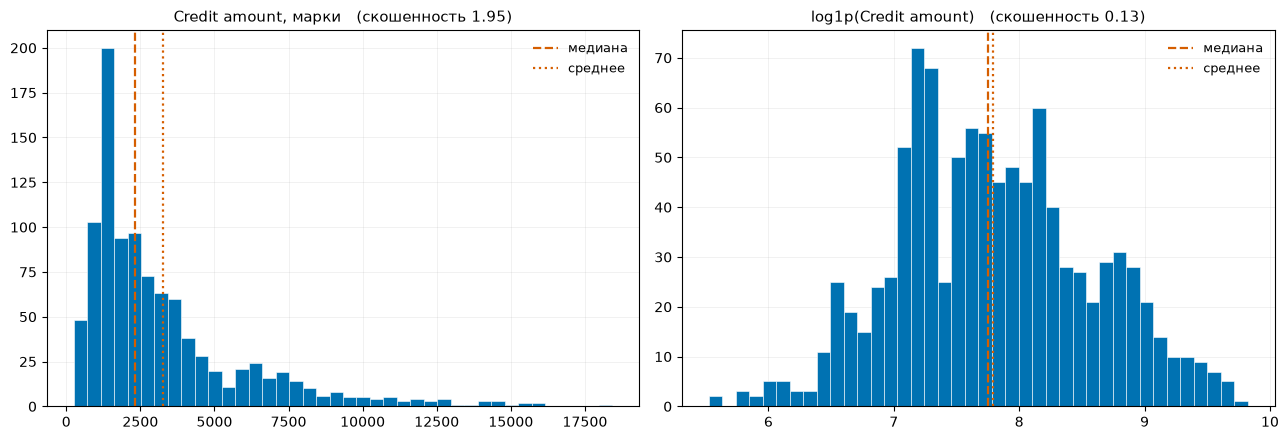

                        скошенн.  макс. z  |z| > 3
Credit amount               1.95     5.37       25
log1p(Credit amount)        0.13     2.62        0


In [19]:
data["Credit amount"] = np.log1p(data["Credit amount"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (values, title) in zip(axes, [(df["Credit amount"], "Credit amount, марки"),
                                      (data["Credit amount"], "log1p(Credit amount)")]):
    ax.hist(values, bins=40, color=COLOR_MAIN, edgecolor="white", linewidth=0.4)
    ax.axvline(values.median(), color=COLOR_REF, linestyle="--", linewidth=1.6, label="медиана")
    ax.axvline(values.mean(), color=COLOR_REF, linestyle=":", linewidth=1.6, label="среднее")
    ax.set_title(f"{title}   (скошенность {skew(values):.2f})", fontsize=11)
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"{'':22} {'скошенн.':>9} {'макс. z':>8} {'|z| > 3':>8}")
for label, values in [("Credit amount", df["Credit amount"]), ("log1p(Credit amount)", data["Credit amount"])]:
    z = (values - values.mean()) / values.std()
    print(f"{label:22} {skew(values):9.2f} {z.max():8.2f} {(z.abs() > 3).sum():8d}")

Скошенность упала с 1,95 до 0,13, за тремя сигмами не осталось никого вместо 25, самая дальняя точка переехала с 5,37 сигмы на 2,62. Хвоста больше нет.

`Age` и `Duration` не трогаем: у них скошенность около 1,0, логарифм дал бы косметический эффект, а читаемость признака испортил бы.

### Шаг 4. Отделение метки `Risk`

Вынимаем метку до сборки матрицы. Так утечка становится невозможной: `Risk` просто нет в объекте, из которого собирается `X`.

In [20]:
y_risk = (data.pop("Risk") == "bad").astype(int)

print(f"колонок осталось в data   : {data.shape[1]}")
print(f"'Risk' среди них          : {'Risk' in data.columns}")
print(f"проблемных займов в метке : {y_risk.sum()} ({y_risk.mean():.1%})")

колонок осталось в data   : 9
'Risk' среди них          : False
проблемных займов в метке : 300 (30.0%)


### Шаг 5. Порядковое кодирование

`Job` уже число 0…3 по возрастанию квалификации — трогать не нужно.

Уровни счетов задаём списком вручную. `LabelEncoder` здесь не подходит: он сортирует по алфавиту, и совпадение алфавита со шкалой достатка было бы чистой случайностью.

Строкам "нет счёта" ставим среднее по остальным уровням. Это значит "о достатке ничего не известно" — в отличие от нуля, который означал бы "достаток нулевой". По п. 2 выводов EDA ноль был бы неверен.

In [21]:
# Порядок задаём списком, а не LabelEncoder: тот сортирует по алфавиту.
ACCOUNT_ORDERS = {
    "Saving accounts":  ["little", "moderate", "quite rich", "rich"],
    "Checking account": ["little", "moderate", "rich"],
}

levels = {}
for c, order in ACCOUNT_ORDERS.items():
    coded = data[c].map({v: i + 1 for i, v in enumerate(order)})
    # NaN тут ровно у строк "нет счёта": их не было в order.
    levels[c] = coded.fillna(coded.mean())
    print(f"{c:18} {' < '.join(order)}  ->  1 … {len(order)}")
    print(f"{'':18} нет счёта -> {coded.mean():.3f}")

Saving accounts    little < moderate < quite rich < rich  ->  1 … 4
                   нет счёта -> 1.457
Checking account   little < moderate < rich  ->  1 … 3
                   нет счёта -> 1.652


### Шаг 6. Факт отсутствия счёта отдельной колонкой

Само по себе "счёта нет" — полезная информация (п. 1 и 2 выводов EDA), её не выбрасываем, а кладём в свою колонку.

Здесь видно, зачем на прошлом шаге был нужен именно средний заполнитель. Если бы поставили ноль, колонка уровня и колонка-индикатор оказались бы почти одним признаком, и "нет счёта" вошло бы в расстояние дважды. Проверяем корреляцией.

In [22]:
flags = {c: (data[c] == NO_ACCOUNT).astype(int) for c in ACCOUNT_COLS}

# Контроль: сравниваем два заполнителя по корреляции уровня с индикатором.
print(f"{'колонка':18} {'заполнитель среднее':>21} {'заполнитель 0':>15}")
for c, order in ACCOUNT_ORDERS.items():
    coded = data[c].map({v: i + 1 for i, v in enumerate(order)})
    r_mean = np.corrcoef(coded.fillna(coded.mean()), flags[c])[0, 1]
    r_zero = np.corrcoef(coded.fillna(0.0), flags[c])[0, 1]
    print(f"{c:18} {r_mean:21.4f} {r_zero:15.4f}")

колонка              заполнитель среднее   заполнитель 0
Saving accounts                  -0.0000         -0.5828
Checking account                  0.0000         -0.8438


При нуле корреляция доходит до −0,84: колонки почти повторяют друг друга. При среднем — ровно ноль, признаки независимы.

### Шаг 7. One-hot для категориальных признаков

`Sex` бинарен — хватит одной колонки. `Housing` и `Purpose` разворачиваем.

Оставляем все уровни, без `drop_first`. В регрессии первый уровень опускают, и он уходит в свободный член. У кластеризации свободного члена нет: убрав `Housing_free`, мы получили бы, что клиенты с бесплатным жильём кодируются нулями и потому оказываются ближе друг к другу, чем остальные.

In [23]:
NOMINAL_HOT = ["Housing", "Purpose"]
dummies = pd.get_dummies(data[NOMINAL_HOT], prefix=NOMINAL_HOT, dtype=int)

# Контроль: сумма по строке равна 1, значит все категории равноудалены.
for prefix in NOMINAL_HOT:
    cols = [c for c in dummies.columns if c.startswith(prefix + "_")]
    print(f"{prefix:10} колонок: {len(cols)}   сумма по строке всегда 1: {(dummies[cols].sum(axis=1) == 1).all()}")
print()
for c in dummies.columns:
    print(f"    {c:32} единиц: {dummies[c].sum():4d}")

Housing    колонок: 3   сумма по строке всегда 1: True
Purpose    колонок: 6   сумма по строке всегда 1: True

    Housing_free                     единиц:  108
    Housing_own                      единиц:  713
    Housing_rent                     единиц:  179
    Purpose_business                 единиц:   97
    Purpose_car                      единиц:  337
    Purpose_education                единиц:   59
    Purpose_furniture/equipment      единиц:  181
    Purpose_other                    единиц:   46
    Purpose_radio/TV                 единиц:  280


### Шаг 8. Матрица признаков

Собираем всё вместе

In [24]:
X = pd.DataFrame(index=data.index)

X["Age"] = data["Age"]
X["Credit amount"] = data["Credit amount"]
X["Duration"] = data["Duration"]
X["Job"] = data["Job"]
X["Saving level"] = levels["Saving accounts"]
X["Checking level"] = levels["Checking account"]
X["No saving account"] = flags["Saving accounts"]
X["No checking account"] = flags["Checking account"]
X["Sex male"] = (data["Sex"] == "male").astype(int)
X = X.join(dummies)

# Понадобится дальше: считать вклад признака в расстояние, а не отдельной колонки.
FEATURE_GROUPS = {
    "Age":              ["Age"],
    "Credit amount":    ["Credit amount"],
    "Duration":         ["Duration"],
    "Job":              ["Job"],
    "Saving accounts":  ["Saving level", "No saving account"],
    "Checking account": ["Checking level", "No checking account"],
    "Sex":              ["Sex male"],
    "Housing":          [c for c in X.columns if c.startswith("Housing_")],
    "Purpose":          [c for c in X.columns if c.startswith("Purpose_")],
}

assert "Risk" not in X.columns, "метка попала в матрицу признаков"
assert X.isna().sum().sum() == 0, "в матрице признаков остались пропуски"
assert all(np.issubdtype(t, np.number) for t in X.dtypes), "остались нечисловые колонки"
assert len(X) == len(df), "потеряны или продублированы строки"
assert sorted(sum(FEATURE_GROUPS.values(), [])) == sorted(X.columns), "группы не покрывают матрицу"

print(f"матрица признаков: {X.shape[0]} строк × {X.shape[1]} колонок")
print()
print(f"{'исходный признак':18} {'колонок':>8}  колонки матрицы")
for name, cols in FEATURE_GROUPS.items():
    print(f"{name:18} {len(cols):8d}  {', '.join(cols)}")

матрица признаков: 1000 строк × 18 колонок

исходный признак    колонок  колонки матрицы
Age                       1  Age
Credit amount             1  Credit amount
Duration                  1  Duration
Job                       1  Job
Saving accounts           2  Saving level, No saving account
Checking account          2  Checking level, No checking account
Sex                       1  Sex male
Housing                   3  Housing_free, Housing_own, Housing_rent
Purpose                   6  Purpose_business, Purpose_car, Purpose_education, Purpose_furniture/equipment, Purpose_other, Purpose_radio/TV


In [25]:
X.head()

,Age,Credit amount,Duration,Job,Saving level,Checking level,No saving account,No checking account,Sex male,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_education,Purpose_furniture/equipment,Purpose_other,Purpose_radio/TV
0,67,7.064759,6,2,1.456548,1.000000,1,0,1,0,1,0,0,0,0,0,0,1
1,22,8.691483,48,2,1.000000,2.000000,0,0,0,0,1,0,0,0,0,0,0,1
2,49,7.648263,12,1,1.000000,1.651815,0,1,1,0,1,0,0,0,1,0,0,0
3,45,8.972464,42,2,1.000000,1.000000,0,0,1,1,0,0,0,0,0,1,0,0
4,53,8.491055,24,2,1.000000,1.000000,0,0,1,1,0,0,0,1,0,0,0,0


Девять признаков превратились в 18 колонок. Все числовые, пропусков нет, метки нет

## Масштабирование

### Шаг 1. Сколько весит признак без масштабирования

Расстояние — это корень из суммы квадратов разностей по колонкам. Значит, вес колонки определяется её дисперсией. Считаем доли.

In [26]:
def distance_weight(matrix, columns, groups):
    """Доля исходного признака в квадрате евклидова расстояния.
    Считаем через дисперсию: средний квадрат разности двух случайных точек
    по колонке равен удвоенной дисперсии, поэтому доли дисперсий и есть доли вклада."""
    var = pd.Series(np.asarray(matrix, dtype=float).var(axis=0), index=columns)
    return pd.Series({name: var[cols].sum() / var.sum() for name, cols in groups.items()})


# "Как есть" — это Credit amount в марках, поэтому возвращаем исходные значения.
X_raw = X.copy()
X_raw["Credit amount"] = df["Credit amount"].to_numpy()

w_raw = distance_weight(X_raw, X.columns, FEATURE_GROUPS).sort_values(ascending=False)

print(f"{'признак':18} {'вес в расстоянии':>18}")
for name, w in w_raw.items():
    print(f"{name:18} {w:17.5%}")
print()
print(f"{'Credit amount один':22} {w_raw['Credit amount']:13.5%}")
print(f"{'все остальные восемь':22} {1 - w_raw['Credit amount']:13.5%}")

признак              вес в расстоянии
Credit amount              99.99651%
Duration                    0.00182%
Age                         0.00162%
Saving accounts             0.00001%
Purpose                     0.00001%
Checking account            0.00001%
Housing                     0.00001%
Job                         0.00001%
Sex                         0.00000%

Credit amount один         99.99651%
все остальные восемь        0.00349%


`Credit amount` забирает 99,9965% расстояния, остальные восемь признаков вместе — 0,0035%

### Шаг 2. Что при этом получается на самом деле

Проверим последствие: запустим один и тот же алгоритм на немасштабированной и масштабированной матрице и сравним разбиения. `adjusted_rand_score` равен 1 при полном совпадении и колеблется около 0, если разбиения не связаны.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

RANDOM_STATE = 42
N_CLUSTERS = 3

X_std = StandardScaler().fit_transform(X)
X_mm = MinMaxScaler().fit_transform(X)
VARIANTS = {"без масштабирования": X_raw, "StandardScaler": X_std, "MinMaxScaler": X_mm}

labels = {name: KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit_predict(m)
          for name, m in VARIANTS.items()}

print(f"совпадение разбиений при k = {N_CLUSTERS}:")
print(f"    без масшт. ~ StandardScaler : {adjusted_rand_score(labels['без масштабирования'], labels['StandardScaler']):+.4f}")
print(f"    без масшт. ~ MinMaxScaler   : {adjusted_rand_score(labels['без масштабирования'], labels['MinMaxScaler']):+.4f}")
print(f"    StandardScaler ~ MinMax     : {adjusted_rand_score(labels['StandardScaler'], labels['MinMaxScaler']):+.4f}")

совпадение разбиений при k = 3:
    без масшт. ~ StandardScaler : +0.0574
    без масшт. ~ MinMaxScaler   : +0.0272
    StandardScaler ~ MinMax     : +0.4723


In [28]:
# Если кластеры на сырых данных — это интервалы сумм, их границы не пересекутся.
raw_labels = labels["без масштабирования"]
order = df.groupby(raw_labels)["Credit amount"].median().sort_values().index

print("кластеры без масштабирования, диапазоны Credit amount:")
bounds = []
for c in order:
    s = df["Credit amount"][raw_labels == c]
    bounds.append((s.min(), s.max()))
    print(f"    кластер {c}:  {s.min():6.0f} … {s.max():6.0f} марок   n = {len(s):4d}")

overlap = any(bounds[i][1] >= bounds[i + 1][0] for i in range(len(bounds) - 1))
print()
print(f"    интервалы пересекаются: {'да' if overlap else 'нет'}")

кластеры без масштабирования, диапазоны Credit amount:
    кластер 1:     250 …   3812 марок   n =  728
    кластер 2:    3832 …   8648 марок   n =  216
    кластер 0:    8858 …  18424 марок   n =   56

    интервалы пересекаются: нет


In [29]:
print(f"силуэт при k = {N_CLUSTERS}:")
for name, matrix in VARIANTS.items():
    print(f"    {name:20} {silhouette_score(matrix, labels[name]):.4f}")

силуэт при k = 3:
    без масштабирования  0.6479
    StandardScaler       0.1761
    MinMaxScaler         0.1667


Три вывода из этих ячеек.

**Разбиения не совпадают.** `adjusted_rand_score` 0,057 и 0,027 — это уровень случайного совпадения. Масштабирование не уточняет результат, а даёт другой ответ.

**Кластеры на сырых данных — просто интервалы сумм займа**: 250…3812 марок (728 клиентов), 3832…8648 (216), 8858…18424 (56), без пересечений. Восемнадцать колонок на входе, одномерная сортировка на выходе.

**Силуэт указывает на худший вариант.** На сырых данных он 0,648, на масштабированных 0,176. По учебнику 0,65 — "выраженная структура", 0,18 — "структуры нет". Причина: силуэт меряет геометрию кластеров в той метрике, которую ему дали. Одномерная задача решается идеально, поэтому и оценка высокая. Высокий силуэт здесь означает не "нашли структуру", а "решили задачу проще поставленной".

Отсюда правило на будущее: силуэт нельзя сравнивать между разными способами подготовки данных — только между разными k и алгоритмами на одной матрице.

### Шаг 3. Какой скейлер выбрать

Масштабировать надо — это ясно. Два обычных варианта делают разное:

- `StandardScaler` вычитает среднее и делит на std. После него дисперсия каждой колонки равна 1, то есть все **колонки** весят одинаково.
- `MinMaxScaler` растягивает колонку на отрезок [0, 1]. Дисперсии остаются разными.

Считаем вес каждого исходного признака при обоих вариантах.

In [30]:
weights = pd.DataFrame({name: distance_weight(m, X.columns, FEATURE_GROUPS)
                        for name, m in VARIANTS.items()})
weights.insert(0, "колонок", [len(c) for c in FEATURE_GROUPS.values()])

print(f"{'признак':18} {'колонок':>8} {'без масшт.':>12} {'Standard':>10} {'MinMax':>9}")
for name, r in weights.iterrows():
    print(f"{name:18} {r['колонок']:8.0f} {r['без масштабирования']:11.4%} "
          f"{r['StandardScaler']:9.2%} {r['MinMaxScaler']:8.2%}")

QUANT_ROWS = ["Age", "Credit amount", "Duration"]
NOMINAL_ROWS = ["Sex", "Housing", "Purpose"]
print()
for label, rows in [("три количественных", QUANT_ROWS), ("три категориальных", NOMINAL_ROWS)]:
    print(f"{label:18} {weights.loc[rows, 'колонок'].sum():8.0f} "
          f"{weights.loc[rows, 'без масштабирования'].sum():11.4%} "
          f"{weights.loc[rows, 'StandardScaler'].sum():9.2%} "
          f"{weights.loc[rows, 'MinMaxScaler'].sum():8.2%}")

признак             колонок   без масшт.   Standard    MinMax
Age                       1     0.0016%     5.56%    1.97%
Credit amount             1    99.9965%     5.56%    1.55%
Duration                  1     0.0018%     5.56%    1.50%
Job                       1     0.0000%     5.56%    2.26%
Saving accounts           2     0.0000%    11.11%   10.40%
Checking account          2     0.0000%    11.11%   14.52%
Sex                       1     0.0000%     5.56%   10.20%
Housing                   3     0.0000%    16.67%   21.36%
Purpose                   6     0.0000%    33.33%   36.25%

три количественных        3   100.0000%    16.67%    5.02%
три категориальных       10     0.0000%    55.56%   67.80%


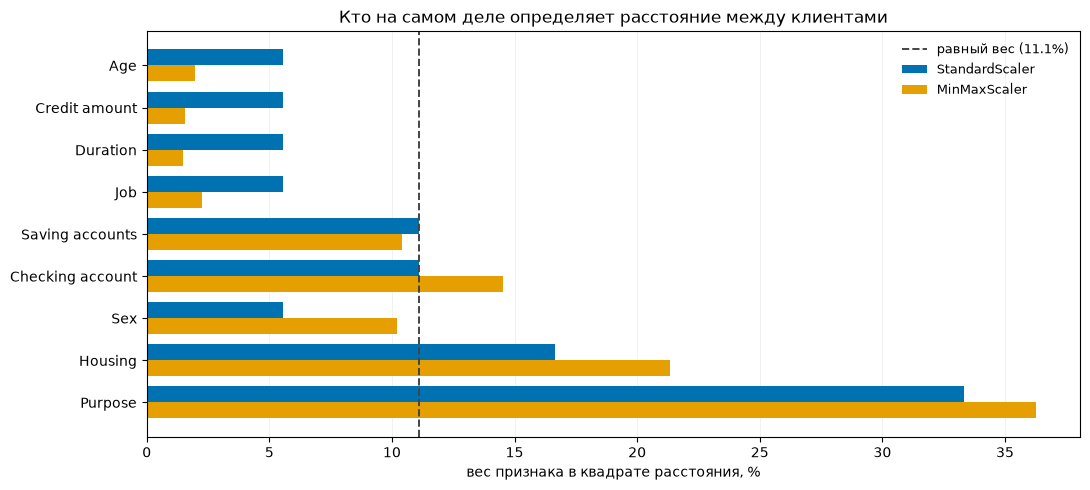

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))

names = list(FEATURE_GROUPS)
y = np.arange(len(names))
h = 0.38
ax.barh(y - h / 2, weights.loc[names, "StandardScaler"] * 100, h, color="#0072B2", label="StandardScaler")
ax.barh(y + h / 2, weights.loc[names, "MinMaxScaler"] * 100, h, color="#E69F00", label="MinMaxScaler")
# Ориентир: сколько весил бы признак, будь все девять равноправны.
ax.axvline(100 / len(names), color="#444", linestyle="--", linewidth=1.4,
           label=f"равный вес ({100 / len(names):.1f}%)")

ax.set_yticks(y)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("вес признака в квадрате расстояния, %")
ax.set_title("Кто на самом деле определяет расстояние между клиентами", fontsize=12)
ax.grid(alpha=0.25, linewidth=0.5, axis="x")
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Равного веса не даёт ни один скейлер, и виноват в этом не скейлер, а one-hot.

`StandardScaler` уравнивает колонки, а не признаки. Колонок 18, каждая получает 1/18 = 5,56%. Но у `Purpose` шесть колонок, поэтому он забирает 33,3%, у `Housing` три — 16,7%, а `Age` остаётся с 5,6%. Цель займа вшестеро важнее возраста только потому, что у неё шесть вариантов ответа.

`MinMaxScaler` перекос усиливает: три количественных признака получают вместе 5,0% против 16,7% у `StandardScaler`. Причина в том, что после растяжения на [0, 1] значения числового признака собираются у середины отрезка, и дисперсия выходит маленькой: 0,033 у логарифма суммы займа, 0,041 у возраста. У бинарной колонки значения сидят строго на концах, и дисперсия куда больше — 0,214 у `Sex`. В итоге сумма займа, срок и возраст вместе весят меньше, чем один пол клиента.

**Берём `StandardScaler`**: количественные признаки сохраняют втрое больший голос, а перекос предсказуем — он ровно пропорционален числу колонок. У `MinMaxScaler` веса зависят ещё и от наполненности категорий, то есть от случайного состава выборки.

Перекос в пользу `Purpose` при этом остаётся.

### Шаг 4. Итоговая матрица

In [32]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

assert "Risk" not in X_scaled.columns, "метка попала в матрицу признаков"
assert X_scaled.isna().sum().sum() == 0, "после масштабирования появились пропуски"
assert np.abs(X_scaled.mean()).max() < 1e-10, "средние не занулились"
assert np.abs(X_scaled.std(ddof=0) - 1).max() < 1e-10, "дисперсии не единичные"

print(f"итоговая матрица : {X_scaled.shape[0]} строк × {X_scaled.shape[1]} колонок")
print(f"метка отдельно   : y_risk, {y_risk.mean():.1%} проблемных")
print()
print(f"{'колонка':30} {'среднее':>10} {'std':>8} {'min':>8} {'max':>8}")
for c in X_scaled.columns:
    s = X_scaled[c]
    print(f"{c:30} {s.mean():10.1e} {s.std(ddof=0):8.4f} {s.min():8.2f} {s.max():8.2f}")

итоговая матрица : 1000 строк × 18 колонок
метка отдельно   : y_risk, 30.0% проблемных

колонка                           среднее      std      min      max
Age                               5.3e-17   1.0000    -1.46     3.47
Credit amount                     4.2e-16   1.0000    -2.92     2.62
Duration                          1.1e-16   1.0000    -1.40     4.24
Job                               5.7e-17   1.0000    -2.91     1.68
Saving level                      6.0e-17   1.0000    -0.58     3.24
Checking level                   -4.7e-16   1.0000    -1.27     2.63
No saving account                 4.3e-17   1.0000    -0.47     2.11
No checking account              -8.2e-17   1.0000    -0.81     1.24
Sex male                          6.6e-17   1.0000    -1.49     0.67
Housing_free                      3.9e-17   1.0000    -0.35     2.87
Housing_own                       5.3e-17   1.0000    -1.58     0.63
Housing_rent                     -6.4e-17   1.0000    -0.47     2.14
Purpose_busines

### Почему масштабирование обязательно при кластеризации

**Масштабирование — это назначение весов признакам.** Кластеризация не считает ничего, кроме расстояний. Вес признака в ответе равен доле его дисперсии в общей сумме, а дисперсия зависит от единиц измерения. Та же сумма займа в тысячах марок вместо марок весила бы в миллион раз меньше.

**Не масштабировать — это тоже решение.** Это выбор взвесить признаки пропорционально квадратам их размахов.

**У классификатора такой проблемы нет, а здесь есть.** Там неудачный признак виден по качеству на отложенной выборке, а деревьям масштаб вообще безразличен. У кластеризации арбитра нет: любое разбиение, оптимальное в заданной метрике, для неё правильное. Единственный источник информации о важности признака — та дисперсия, которую мы задали.

**Чего масштабирование не делает:**

- не выравнивает признаки, а только колонки — `Purpose` весит 33,3% против 5,6% у `Age` из-за one-hot, и скейлер тут ни при чём;
- не устраняет двойной счёт `Credit amount` и `Duration` (корреляция 0,625);
- не лечит форму — хвост суммы займа гасили логарифмом отдельно;
- не нужно алгоритмам, которые не считают расстояний и дисперсий.

## Кластеризация

Три алгоритма на матрице `X_scaled`: KMEANS, иерархическая и DBSCAN. Число кластеров подбираем методом локтя и по силуэту.

### Снижение размерности для визуализации

Кластеризовать будем на всех 18 колонках, а проекции нужны только для картинок. Считаем их заранее, чтобы показывать результат каждого алгоритма сразу.

две компоненты PCA держат 23.3% дисперсии
на 90% нужно 13 компонент из 18


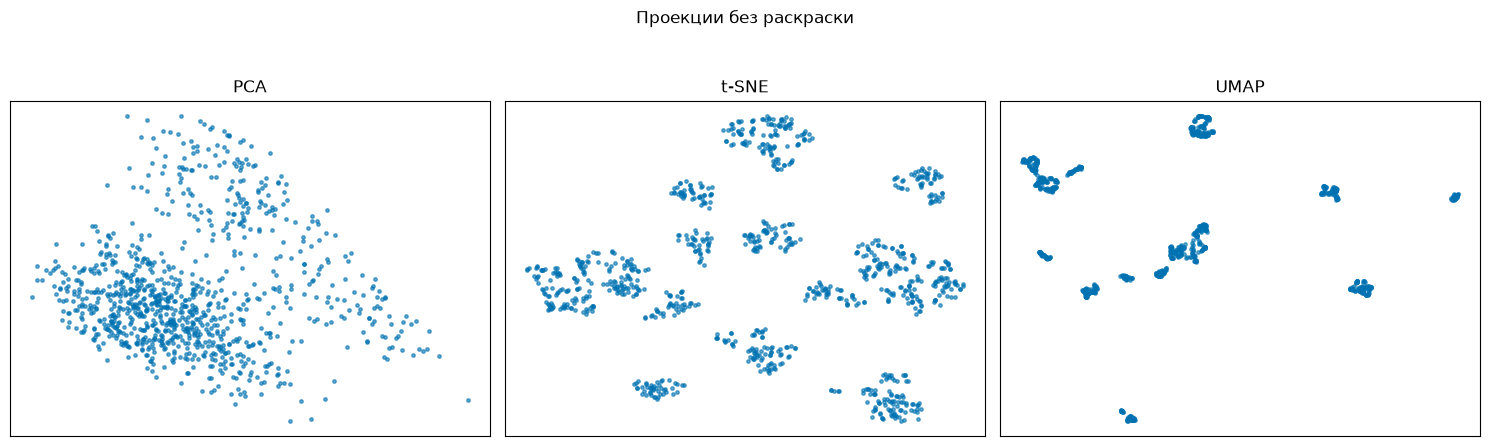

In [33]:
import warnings

# umap при заданном random_state предупреждает про n_jobs, tqdm — про ipywidgets.
warnings.simplefilter("ignore")

from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram
from umap import UMAP

K_RANGE = range(2, 11)

# Палитра Okabe-Ito, различима при дальтонизме. Цветов в ней восемь,
# что делать при большем числе кластеров — в cluster_colors ниже.
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
           "#E69F00", "#56B4E9", "#F0E442", "#000000"]
NOISE_COLOR = "#BBBBBB"

pca = PCA(n_components=2, random_state=RANDOM_STATE)
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca",
            max_iter=1000, random_state=RANDOM_STATE)
umap = UMAP(n_components=2, random_state=RANDOM_STATE)

PROJ = {
    "PCA": pca.fit_transform(X_scaled),
    "t-SNE": tsne.fit_transform(X_scaled),
    "UMAP": umap.fit_transform(X_scaled),
}


def cluster_colors(n):
    """Okabe-Ito различима при дальтонизме, но цветов в ней восемь.
    Если кластеров больше, берём tab20: сначала насыщенные, потом бледные,
    иначе бледные сливаются с серым шумом."""
    if n <= len(PALETTE):
        return PALETTE[:n]
    cmap = plt.get_cmap("tab20")
    order = list(range(0, 20, 2)) + list(range(1, 20, 2))
    return [cmap(order[i % 20]) for i in range(n)]


def show_clusters(labels, title):
    """Одни и те же метки на трёх проекциях. Серым — шум DBSCAN."""
    clusters = [c for c in sorted(set(labels)) if c != -1]
    colors = cluster_colors(len(clusters))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (name, xy) in zip(axes, PROJ.items()):
        noise = labels == -1
        if noise.any():
            ax.scatter(xy[noise, 0], xy[noise, 1], s=5, alpha=0.4, color=NOISE_COLOR)
        for color, cluster in zip(colors, clusters):
            mask = labels == cluster
            ax.scatter(xy[mask, 0], xy[mask, 1], s=6, alpha=0.7, color=color)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# Сколько компонент нужно, чтобы удержать 90% дисперсии.
cumsum = np.cumsum(PCA().fit(X_scaled).explained_variance_ratio_)
print(f"две компоненты PCA держат {cumsum[1]:.1%} дисперсии")
print(f"на 90% нужно {np.argmax(cumsum >= 0.9) + 1} компонент из {X_scaled.shape[1]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, xy) in zip(axes, PROJ.items()):
    ax.scatter(xy[:, 0], xy[:, 1], s=6, alpha=0.6, color=COLOR_MAIN)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Проекции без раскраски")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Две компоненты PCA держат всего 23,3% дисперсии, на 90% нужно 13 компонент из 18 — линейно сжимать здесь нечего, и на PCA всё сливается в одно облако.

t-SNE и UMAP рисуют десяток раздельных островов. Разрывы в облаке есть, вопрос в том, окажутся ли они кластерами клиентов.

### 1. KMEANS

Число кластеров подбираем локтем по инерции и по среднему силуэту.

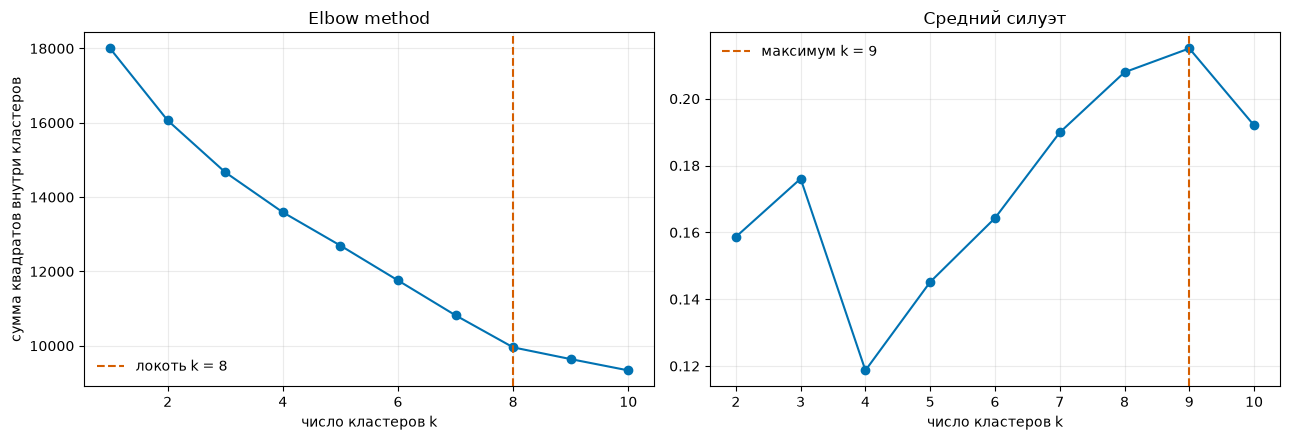

локоть           : k = 8, D = 0.37
максимум силуэта : k = 9, силуэт = 0.2151
размеры при k = 8 : [227, 219, 149, 122, 94, 84, 59, 46]


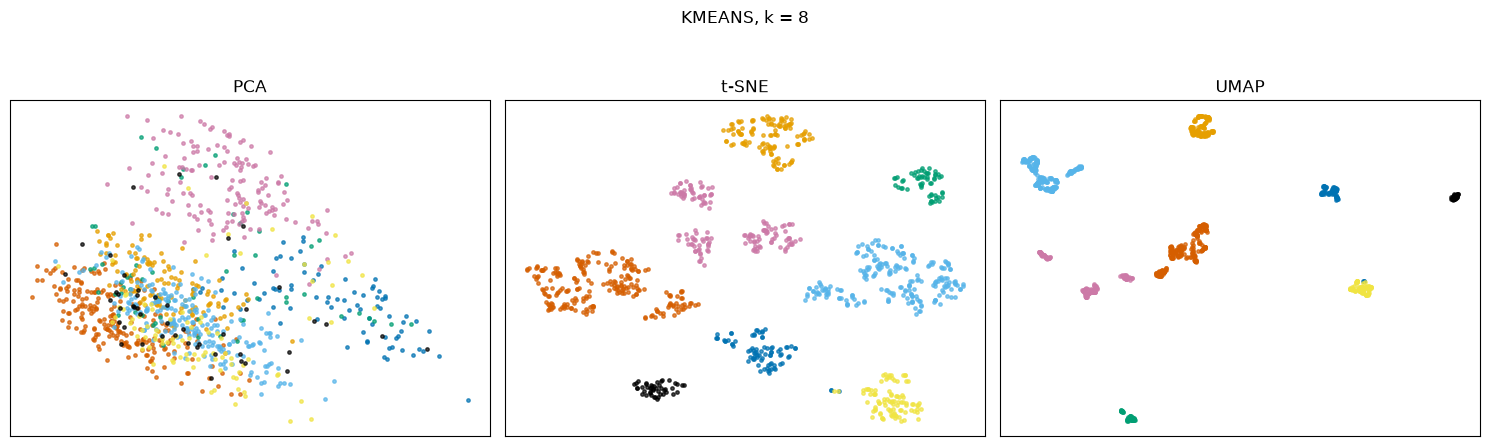

In [34]:
# Инерция считается и при одном кластере, силуэту нужно минимум два.
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(kmeans.inertia_)

kmeans_labels = {}
kmeans_sil = []
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    kmeans_labels[k] = kmeans.labels_
    kmeans_sil.append(silhouette_score(X_scaled, kmeans.labels_))

# Критерий локтя: отношение следующего падения инерции к текущему.
D = []
for i in range(1, 9):
    D.append((inertia[i] - inertia[i + 1]) / (inertia[i - 1] - inertia[i]))

K_ELBOW = D.index(min(D)) + 2
K_SIL = list(K_RANGE)[kmeans_sil.index(max(kmeans_sil))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(1, 11), inertia, marker="o", color=COLOR_MAIN)
axes[0].axvline(K_ELBOW, color=COLOR_REF, linestyle="--", label=f"локоть k = {K_ELBOW}")
axes[0].set_title("Elbow method")
axes[0].set_ylabel("сумма квадратов внутри кластеров")
axes[1].plot(K_RANGE, kmeans_sil, marker="o", color=COLOR_MAIN)
axes[1].axvline(K_SIL, color=COLOR_REF, linestyle="--", label=f"максимум k = {K_SIL}")
axes[1].set_title("Средний силуэт")
for ax in axes:
    ax.set_xlabel("число кластеров k")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"локоть           : k = {K_ELBOW}, D = {min(D):.2f}")
print(f"максимум силуэта : k = {K_SIL}, силуэт = {max(kmeans_sil):.4f}")
print(f"размеры при k = {K_ELBOW} : "
      f"{sorted(pd.Series(kmeans_labels[K_ELBOW]).value_counts().tolist(), reverse=True)}")

show_clusters(kmeans_labels[K_ELBOW], f"KMEANS, k = {K_ELBOW}")

Локоть на k = 8: следующее падение инерции составляет 37% от предыдущего, до этого отношение держалось около 0,8…1,0. Силуэт растёт до 0,2151 при k = 9, с провалом до 0,1187 при k = 4.

Берём k = 8 по локтю. На UMAP и t-SNE цвета почти совпали с островами: KMEANS разложил объекты по тем же сгущениям, которые видны на проекции.

### 2. Иерархическая кластеризация

Смотрим дендрограмму и силуэт по k. Заодно сравниваем три способа связи — от него результат зависит не меньше, чем от k.

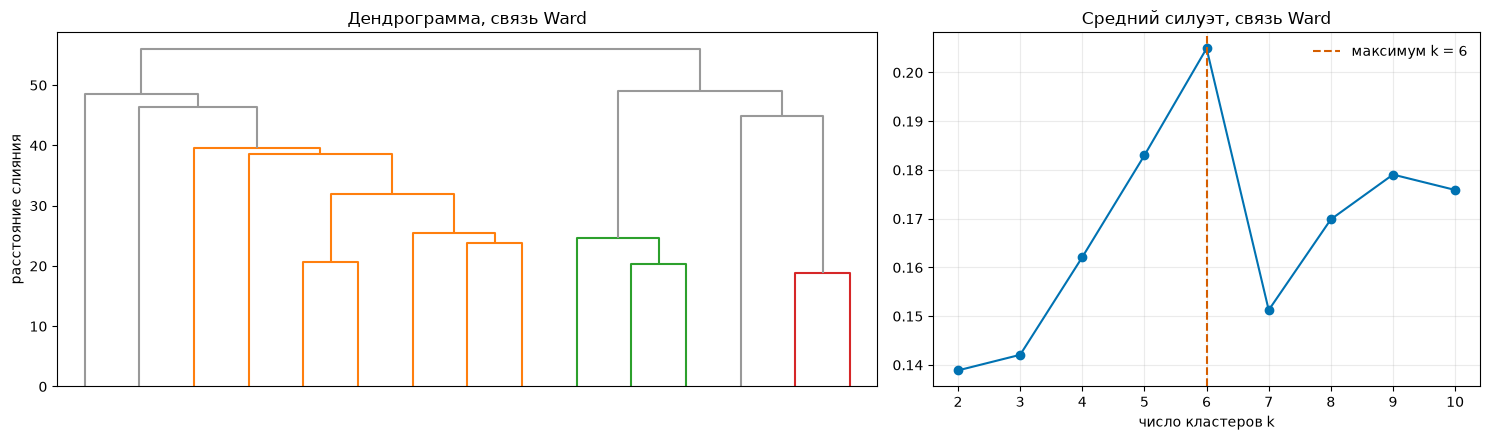

ward      силуэт 0.2049 при k = 6, в крупнейшем кластере 568 из 1000
average   силуэт 0.2284 при k = 2, в крупнейшем кластере 954 из 1000
complete  силуэт 0.1889 при k = 6, в крупнейшем кластере 589 из 1000
размеры при k = 6 : [568, 149, 97, 82, 58, 46]


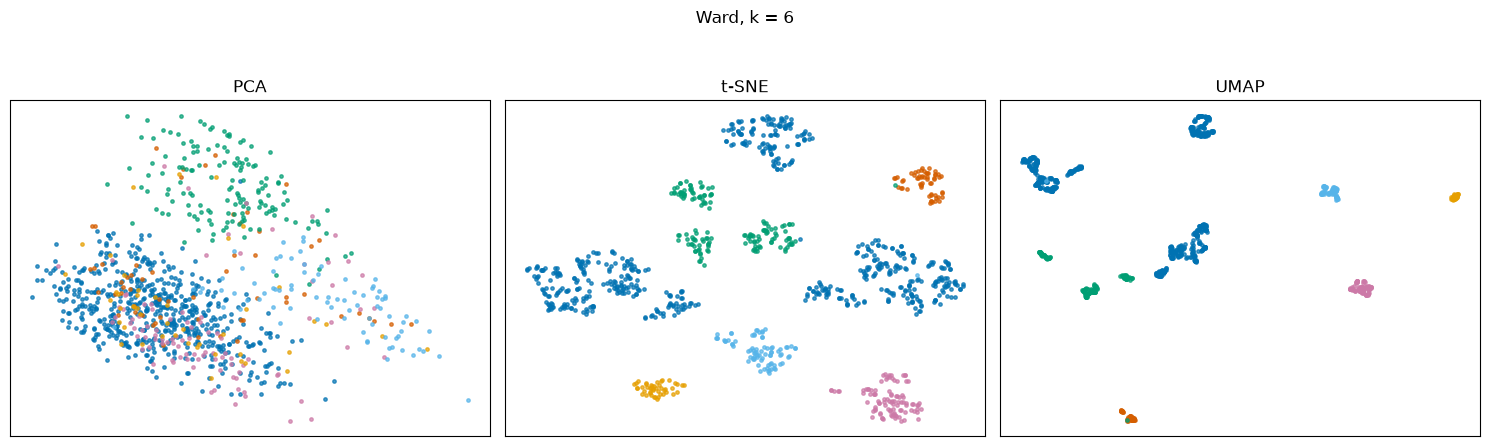

In [35]:
Z = linkage(X_scaled, method="ward")
LINKAGES = ["ward", "average", "complete"]

hier_labels = {}
rows = []
for name in LINKAGES:
    for k in K_RANGE:
        labels = AgglomerativeClustering(n_clusters=k, linkage=name).fit_predict(X_scaled)
        hier_labels[(name, k)] = labels
        rows.append({
            "связь": name,
            "k": k,
            "силуэт": silhouette_score(X_scaled, labels),
            "крупнейший": pd.Series(labels).value_counts().max(),
        })

hier_table = pd.DataFrame(rows)
ward = hier_table[hier_table["связь"] == "ward"]
K_WARD = int(ward.loc[ward["силуэт"].idxmax(), "k"])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[3, 2])
# Полная дендрограмма на 1000 объектов нечитаема, показываем верхние 15 слияний.
dendrogram(Z, truncate_mode="lastp", p=15, ax=axes[0], no_labels=True,
           color_threshold=Z[-5, 2], above_threshold_color="#999999")
axes[0].set_title("Дендрограмма, связь Ward")
axes[0].set_ylabel("расстояние слияния")
axes[1].plot(ward["k"], ward["силуэт"], marker="o", color=COLOR_MAIN)
axes[1].axvline(K_WARD, color=COLOR_REF, linestyle="--", label=f"максимум k = {K_WARD}")
axes[1].set_title("Средний силуэт, связь Ward")
axes[1].set_xlabel("число кластеров k")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

for name in LINKAGES:
    best = hier_table[hier_table["связь"] == name].sort_values("силуэт").iloc[-1]
    print(f"{name:9} силуэт {best['силуэт']:.4f} при k = {int(best['k'])}, "
          f"в крупнейшем кластере {int(best['крупнейший'])} из {len(X_scaled)}")

ward_labels = hier_labels[("ward", K_WARD)]
print(f"размеры при k = {K_WARD} : "
      f"{sorted(pd.Series(ward_labels).value_counts().tolist(), reverse=True)}")

show_clusters(ward_labels, f"Ward, k = {K_WARD}")

Дендрограмма ветвится равномерно, явного уровня среза нет. Силуэт Ward максимален при k = 6 (0,2049).

Связь важнее k: у `average` силуэт выше всех, 0,2284 при k = 2, но в крупнейшем кластере 954 объекта из 1000 — это отделение горстки точек от всей выборки. `complete` даёт 0,1889 при 589. Сбалансирован только `ward`: 568 в крупнейшем.

На проекциях видно, чем Ward отличается от KMEANS: он склеил несколько островов в один синий кластер на 568 объектов.

### 3. DBSCAN

Числа кластеров у DBSCAN нет, задаётся плотность: радиус `eps` и `min_samples`. Обычная рекомендация `min_samples = 2 × размерность` даёт здесь 36 — проверяем, не слишком ли это строго, и перебираем оба параметра сеткой.

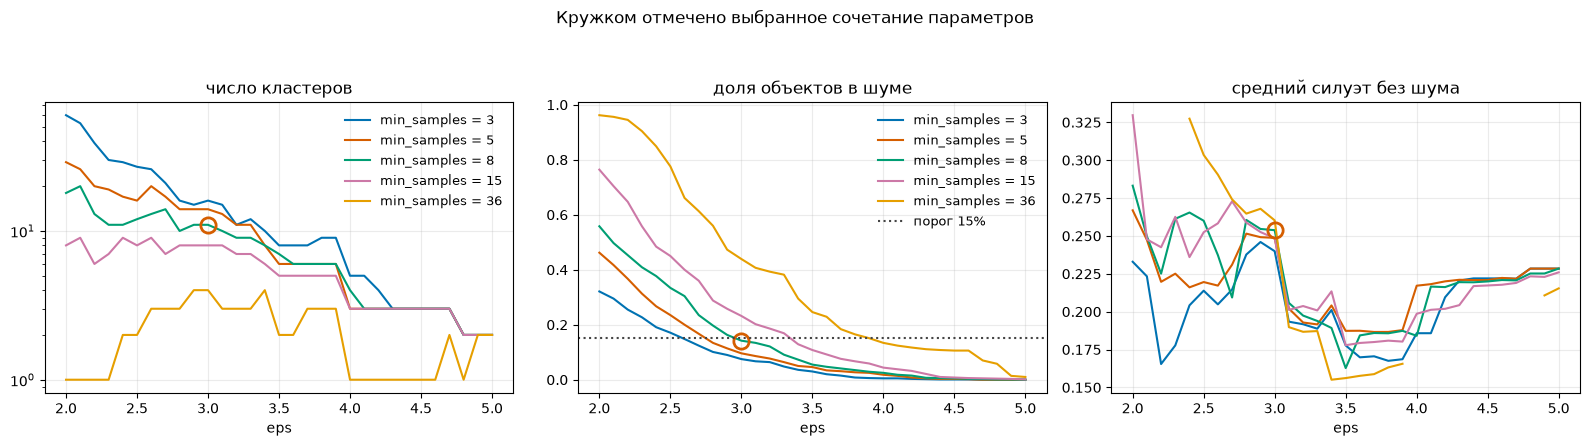

пригодных сочетаний: 18 из 155
выбрано: min_samples = 8, eps = 3.0

лучшее пригодное решение при каждом min_samples:
 min_samples  eps  кластеров  доля шума  силуэт  крупнейший
           3  2.9         15      0.090   0.246         225
           5  2.8         14      0.134   0.251         221
           8  3.0         11      0.142   0.254         225

что даёт min_samples = 36 из рекомендации, лучшее по силуэту:
 min_samples  eps  кластеров  доля шума  силуэт  крупнейший
        36.0  2.4        2.0      0.849   0.327       115.0

итог: 11 кластеров, 142 объектов в шуме (14.2%), силуэт 0.2538
размеры: [225, 214, 121, 73, 55, 45, 44, 29, 22, 21, 9]


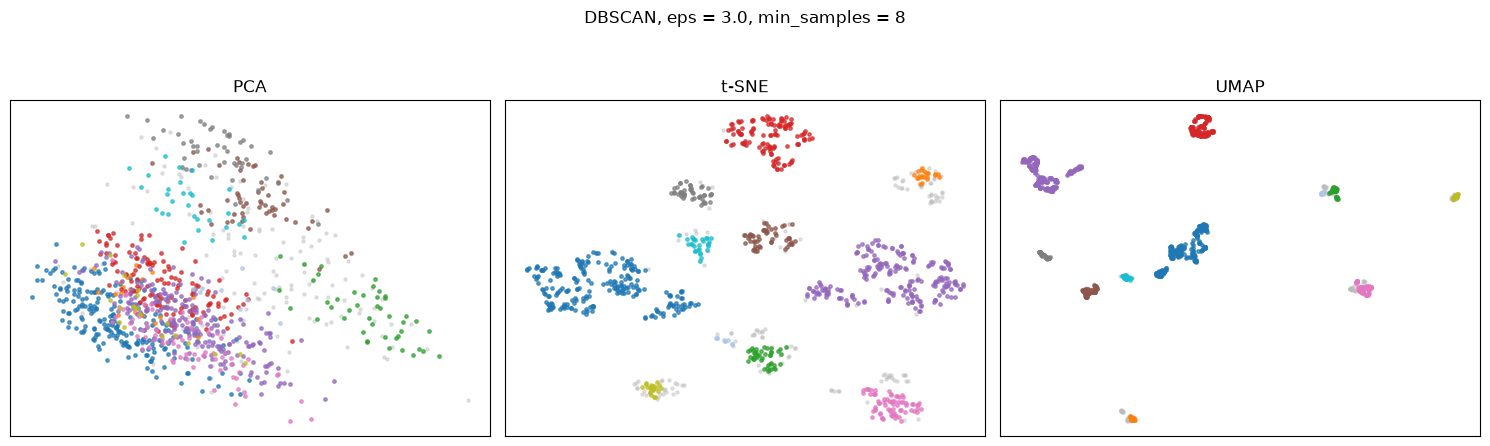

In [36]:
# Обычная рекомендация min_samples = 2 × размерность даёт здесь 36 — очень строго.
# Поэтому перебираем оба параметра, а не только eps.
MS_GRID = [3, 5, 8, 15, 36]
EPS_GRID = np.round(np.arange(2.0, 5.01, 0.1), 2)

# Что считаем пригодным решением, а не отбором горстки точек.
MAX_NOISE = 0.15        # в шуме не больше 15% выборки
MAX_BIGGEST = 0.5       # крупнейший кластер меньше половины выборки
MIN_CLUSTERS = 3


def run_dbscan(eps, min_samples):
    """Один запуск: метки, число кластеров, объём шума, силуэт без шума."""
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
    real = labels != -1
    n_clusters = len(set(labels[real]))
    score = silhouette_score(X_scaled[real], labels[real]) if n_clusters > 1 else None
    return labels, n_clusters, int((~real).sum()), score


rows = []
for min_samples in MS_GRID:
    for eps in EPS_GRID:
        labels, n_clusters, noise, score = run_dbscan(eps, min_samples)
        real = labels != -1
        biggest = pd.Series(labels[real]).value_counts().max() if n_clusters else 0
        rows.append({"min_samples": min_samples, "eps": eps, "кластеров": n_clusters,
                     "доля шума": noise / len(X_scaled), "силуэт": score, "крупнейший": biggest})
grid = pd.DataFrame(rows)

allowed = grid[(grid["доля шума"] < MAX_NOISE)
               & (grid["крупнейший"] < MAX_BIGGEST * len(X_scaled))
               & (grid["кластеров"] >= MIN_CLUSTERS)]
best = allowed.loc[allowed["силуэт"].idxmax()]
DB_EPS, DB_MS = float(best["eps"]), int(best["min_samples"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
panels = [("кластеров", "число кластеров"), ("доля шума", "доля объектов в шуме"),
          ("силуэт", "средний силуэт без шума")]
for ax, (column, title) in zip(axes, panels):
    for color, min_samples in zip(PALETTE, MS_GRID):
        line = grid[grid["min_samples"] == min_samples]
        ax.plot(line["eps"], line[column], color=color, label=f"min_samples = {min_samples}")
    ax.plot(best["eps"], best[column], marker="o", ms=11, mfc="none", mew=2, color=COLOR_REF)
    ax.set_title(title)
    ax.set_xlabel("eps")
    ax.grid(alpha=0.25)
axes[0].set_yscale("log")   # при min_samples = 3 кластеров под сотню, при 36 — единицы
axes[1].axhline(MAX_NOISE, color="#444", linestyle=":", label=f"порог {MAX_NOISE:.0%}")
axes[0].legend(frameon=False, fontsize=9)
axes[1].legend(frameon=False, fontsize=9)
fig.suptitle("Кружком отмечено выбранное сочетание параметров")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f"пригодных сочетаний: {len(allowed)} из {len(grid)}")
print(f"выбрано: min_samples = {DB_MS}, eps = {DB_EPS}\n")
print("лучшее пригодное решение при каждом min_samples:")
print(allowed.sort_values("силуэт", ascending=False).groupby("min_samples").head(1)
      .sort_values("min_samples").round(3).to_string(index=False))

print("\nчто даёт min_samples = 36 из рекомендации, лучшее по силуэту:")
strict = grid[(grid["min_samples"] == 36) & grid["силуэт"].notna()]
print(strict.loc[strict["силуэт"].idxmax()].to_frame().T.round(3).to_string(index=False))

db_labels, n_clusters, noise, score = run_dbscan(DB_EPS, DB_MS)
sizes = sorted(pd.Series(db_labels[db_labels != -1]).value_counts().tolist(), reverse=True)
print(f"\nитог: {n_clusters} кластеров, {noise} объектов в шуме ({noise / len(X_scaled):.1%}), "
      f"силуэт {score:.4f}")
print(f"размеры: {sizes}")

show_clusters(db_labels, f"DBSCAN, eps = {DB_EPS}, min_samples = {DB_MS}")

Рекомендация `min_samples = 2 × размерность` здесь не работает. На средней панели жёлтая кривая идёт заметно выше остальных: чтобы шум опустился ниже 15%, при 36 нужен eps = 4,0, а там остаётся уже один кластер. Требование "36 соседей в радиусе eps" в 18-мерном пространстве выполняется редко. Лучшее, что этот параметр даёт по силуэту, — два кластера при 849 объектах в шуме.

Правая панель показывает, почему нельзя выбирать по силуэту: его максимум, 0,327, приходится ровно на ту точку, где в шуме 85% выборки. Силуэт считается по нешумовым точкам, поэтому растёт всякий раз, когда алгоритм выбрасывает сомнительные объекты.

С ограничениями "шума меньше 15%, крупнейший кластер меньше половины выборки, кластеров хотя бы три" подходят 18 сочетаний из 155. Лучшее — `min_samples` = 8 и eps = 3,0: 11 кластеров, 142 объекта в шуме, силуэт 0,2538, размеры от 9 до 225.

### Сравнение трёх решений

In [37]:
RESULTS = {
    f"KMEANS k={K_ELBOW}": kmeans_labels[K_ELBOW],
    f"Ward k={K_WARD}": ward_labels,
    f"DBSCAN eps={DB_EPS}": db_labels,
}

rows = []
for name, labels in RESULTS.items():
    real = labels != -1
    row = {
        "метод": name,
        "кластеров": len(set(labels[real])),
        "шум": int((~real).sum()),
        "силуэт": round(silhouette_score(X_scaled[real], labels[real]), 4),
    }
    for proj_name, xy in PROJ.items():
        row[f"силуэт в {proj_name}"] = round(silhouette_score(xy[real], labels[real]), 3)
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

         метод  кластеров  шум  силуэт  силуэт в PCA  силуэт в t-SNE  силуэт в UMAP
    KMEANS k=8          8    0  0.2079         0.066           0.624          0.785
      Ward k=6          6    0  0.2049         0.126           0.161          0.417
DBSCAN eps=3.0         11  142  0.2538        -0.046           0.588          0.740


Три метода дают три разных ответа: 8, 6 и 11 кластеров. Силуэт у всех в диапазоне 0,20…0,25, причём у DBSCAN он посчитан по 858 объектам из 1000 и с остальными не сравнивается.

In [38]:
def purity(labels, feature):
    """Какую долю кластера в среднем занимает его самый частый уровень признака."""
    return pd.crosstab(labels, feature, normalize="index").max(axis=1).mean()


housing_purpose = data["Housing"] + " / " + data["Purpose"]

rows = []
for k in [3, 6, K_ELBOW]:
    rows.append({"k": k,
                 "Housing": purity(kmeans_labels[k], data["Housing"]),
                 "Purpose": purity(kmeans_labels[k], data["Purpose"]),
                 "Housing × Purpose": purity(kmeans_labels[k], housing_purpose)})
print("средняя чистота кластеров KMEANS:")
print(pd.DataFrame(rows).set_index("k").to_string(float_format="{:.0%}".format))

print(f"\nразмеры кластеров при k = 3 : {sorted(pd.Series(kmeans_labels[3]).value_counts().tolist())}")
print(f"уровни Housing              : {sorted(data['Housing'].value_counts().tolist())}")

real = db_labels != -1
print(f"\nчистота кластеров DBSCAN, по {int(real.sum())} объектам вне шума:")
print(f"    Housing {purity(db_labels[real], data['Housing'].to_numpy()[real]):.0%}, "
      f"Purpose {purity(db_labels[real], data['Purpose'].to_numpy()[real]):.0%}, "
      f"Housing × Purpose {purity(db_labels[real], housing_purpose.to_numpy()[real]):.0%}")

# Контроль: убираем категориальные колонки и кластеризуем заново.
# Случайные метки — ориентир, ниже которого чистота не опускается.
ONEHOT = [c for c in X_scaled.columns if c.startswith(("Housing_", "Purpose_"))] + ["Sex male"]
X_num = X_scaled.drop(columns=ONEHOT)
labels_num = KMeans(n_clusters=K_ELBOW, n_init=10, random_state=RANDOM_STATE).fit_predict(X_num)
labels_random = np.random.default_rng(RANDOM_STATE).integers(0, K_ELBOW, len(X_scaled))

rows = []
for name, labels in [("на всех 18 колонках", kmeans_labels[K_ELBOW]),
                     (f"без категориальных, осталось {X_num.shape[1]}", labels_num),
                     ("случайные метки, ориентир", labels_random)]:
    rows.append({f"KMEANS на {K_ELBOW} кластеров": name,
                 "Housing": purity(labels, data["Housing"]),
                 "Purpose": purity(labels, data["Purpose"]),
                 "Housing × Purpose": purity(labels, housing_purpose)})
print(f"\nчто меняется, если убрать {len(ONEHOT)} категориальных колонок:")
print(pd.DataFrame(rows).set_index(f"KMEANS на {K_ELBOW} кластеров")
      .to_string(float_format="{:.0%}".format))
print(f"\nсилуэт разбиения без категориальных колонок: {silhouette_score(X_num, labels_num):.4f}")

средняя чистота кластеров KMEANS:
   Housing  Purpose  Housing × Purpose
k                                     
3     100%      39%                39%
6      96%      73%                69%
8      89%      88%                78%

размеры кластеров при k = 3 : [108, 179, 713]
уровни Housing              : [108, 179, 713]

чистота кластеров DBSCAN, по 858 объектам вне шума:
    Housing 100%, Purpose 100%, Housing × Purpose 100%

что меняется, если убрать 10 категориальных колонок:
                                Housing  Purpose  Housing × Purpose
KMEANS на 8 кластеров                                              
на всех 18 колонках                 89%      88%                78%
без категориальных, осталось 8      71%      37%                25%
случайные метки, ориентир           71%      34%                23%

силуэт разбиения без категориальных колонок: 0.2194


При k = 3 размеры кластеров 108 / 179 / 713 в точности повторяют уровни `Housing`, чистота 100%. При k = 8 средняя чистота по `Housing` 89%, по `Purpose` 88%. У DBSCAN чистота по `Housing` × `Purpose` ровно 100%: каждый из 11 кластеров целиком состоит из одной комбинации «жильё + цель займа».

Сверка с рабочей гипотезой из EDA.

**Структуры нет, силуэт 0,1…0,2** — сбылось. KMEANS 0,2079 при k = 8, Ward 0,2049 при k = 6, DBSCAN 0,2538. Локоть указывает на k = 8, силуэт растёт до k = 9 — однозначного оптимума нет.

**Разбиение неустойчиво** — сбылось. Три алгоритма дали 8, 6 и 11 кластеров. У иерархической выбор связи меняет ответ сильнее выбора k: `average` при k = 2 даёт силуэт 0,2284 против 0,1389 у `ward`.

**Разбиение определят one-hot колонки** — сбылось буквально. При k = 3 кластеры KMEANS совпали с уровнями `Housing` один в один, у DBSCAN чистота по `Housing` × `Purpose` равна 100%, а без категориальных колонок чистота падает до уровня случайных меток.

Два вывода про метрику. Первый: лучший силуэт достаётся вырожденному решению — у связи `average` это 954 объекта в одном кластере, у DBSCAN 849 объектов в шуме. Второй: у DBSCAN силуэт считается только по нешумовым точкам, поэтому вознаграждает выбрасывание данных. В обоих случаях нужен второй критерий — на размер кластеров или на объём шума.

И про параметры: `min_samples = 2 × размерность` — рекомендация для низкой размерности. При 18 колонках она обессмысливает DBSCAN, отправляя в шум почти всю выборку.

## Интерпретация кластеров

Берём разбиение KMEANS при k = 8 — то, что выбрал локоть. Метка `Risk` в кластеризации не участвовала, поэтому её можно использовать как независимую проверку.

### Средние значения признаков по кластерам

Интерпретируем разбиение KMEANS при k = 8: у него все 1000 объектов получают кластер, тогда как DBSCAN оставляет 142 в шуме, а k выбран локтем. В конце ячейки проверяем, зависит ли вывод от этого выбора.

Считаем в исходных единицах — марках, годах, месяцах, — а не в масштабированных.

In [39]:
CLUSTER = kmeans_labels[K_ELBOW]
NUMERIC = ["Age", "Credit amount", "Duration", "Job"]

# Сумму займа берём из df: в data она логарифмирована и в марках уже не читается.
by_cluster = df.assign(cluster=CLUSTER).groupby("cluster")
table = by_cluster[NUMERIC].mean().round(1)
table.insert(0, "n", by_cluster.size())

# У категориальных признаков среднего нет — берём самый частый уровень и его долю.
for column in ["Housing", "Purpose"]:
    shares = pd.crosstab(CLUSTER, data[column], normalize="index")
    table[column] = shares.idxmax(axis=1)
    table[f"{column}, %"] = (shares.max(axis=1) * 100).round(0).astype(int)

# Risk в кластеризации не участвовал, смотрим его как проверку осмысленности.
table["bad, %"] = (by_cluster["Risk"].apply(lambda s: (s == "bad").mean()) * 100).round(0).astype(int)
print(table.to_string())

overall = ", ".join(f"{c} {df[c].mean():.1f}" for c in NUMERIC)
print(f"\nпо всей выборке: {overall}, bad {(df['Risk'] == 'bad').mean():.0%}")

# Какую долю разброса признака объясняет разбиение на кластеры.
print("\nсколько разброса признака объясняют кластеры:")
for column in NUMERIC:
    within = (df.assign(cluster=CLUSTER).groupby("cluster")[column]
              .apply(lambda s: s.var(ddof=0) * len(s)).sum() / len(df))
    print(f"    {column:16} {1 - within / df[column].var(ddof=0):6.1%}")

# Зависит ли вывод от того, какое разбиение интерпретировать.
rows = []
for name, labels in RESULTS.items():
    real = labels != -1
    row = {"разбиение": name, "кластеров": len(set(labels[real])), "шум": int((~real).sum())}
    for column in NUMERIC:
        values = df[column][real]
        within = (values.groupby(labels[real]).apply(lambda s: s.var(ddof=0) * len(s)).sum()
                  / len(values))
        row[column] = f"{1 - within / values.var(ddof=0):.1%}"
    pair = (data["Housing"] + " / " + data["Purpose"]).to_numpy()[real]
    row["чистота H × P"] = f"{pd.crosstab(labels[real], pair, normalize='index').max(axis=1).mean():.0%}"
    rows.append(row)
print("\nсколько разброса объясняет каждое из трёх разбиений:")
print(pd.DataFrame(rows).to_string(index=False))

           n   Age  Credit amount  Duration  Job Housing  Housing, %              Purpose  Purpose, %  bad, %
cluster                                                                                                      
0         84  44.0         4990.4      26.6  2.2    free         100                  car          65      39
1        227  35.1         2540.5      20.2  1.8     own         100             radio/TV         100      20
2         59  38.3         2879.2      19.7  1.8     own          58            education         100      39
3        149  29.8         2914.4      18.0  1.9    rent         100                  car          42      36
4        122  33.7         3107.5      19.9  1.9     own         100  furniture/equipment         100      30
5        219  36.7         3329.9      19.6  1.9     own         100                  car         100      27
6         94  35.1         4110.4      26.6  1.9     own          81             business         100      34
7         

Закономерности есть, но слабые. Возраст меняется от 29,8 в кластере 3 до 44,0 в кластере 0 при среднем 35,5, сумма займа — от 2540 до 4990 марок при среднем 3271. Разбиение объясняет 9,5% разброса возраста, 6,1% суммы и 5,4% срока: по числовым признакам кластеры почти не различаются.

Зато `Purpose` в шести кластерах из восьми совпадает на 100%, `Housing` — в четырёх. Кластер это не группа похожих клиентов, а клетка таблицы "жильё × цель займа".

Доля проблемных займов ходит от 20% до 39% при среднем 30%. Самый спокойный кластер 1 — свои квартиры и займы на телевизор, самый рискованный кластер 0 — бесплатное жильё и крупные автокредиты.

Выбор разбиения на это не влияет: у Ward та же картина (9,2% и 5,0%), у DBSCAN различия чуть заметнее (12,1% и 11,3%) ценой 142 объектов в шуме, а чистота по "жильё × цель" у него все 100%.

In [ ]:
from scipy.stats import binomtest

BASE = (df["Risk"] == "bad").mean()

rows = []
for cluster in sorted(set(CLUSTER)):
    mask = CLUSTER == cluster
    bad = int((df["Risk"][mask] == "bad").sum())
    test = binomtest(bad, int(mask.sum()), BASE)
    low, high = test.proportion_ci(0.95)
    rows.append({"кластер": cluster, "n": int(mask.sum()), "bad": bad,
                 "доля": f"{bad / mask.sum():.0%}",
                 "95% интервал": f"{low:.0%} … {high:.0%}",
                 "p": round(test.pvalue, 3),
                 "отличие от среднего": "значимо" if test.pvalue < 0.05 else "в пределах шума"})
print(f"доля проблемных займов по кластерам, по всей выборке {BASE:.0%}:")
print(pd.DataFrame(rows).to_string(index=False))

# То же по цели займа: даёт ли кластер что-то сверх обычной группировки.
rows = []
for purpose, group in df.assign(purpose=data["Purpose"]).groupby("purpose"):
    bad = int((group["Risk"] == "bad").sum())
    test = binomtest(bad, len(group), BASE)
    rows.append({"цель займа": purpose, "n": len(group), "доля": f"{bad / len(group):.0%}",
                 "p": round(test.pvalue, 3),
                 "отличие от среднего": "значимо" if test.pvalue < 0.05 else "в пределах шума"})
print("\nто же по цели займа, без всякой кластеризации:")
print(pd.DataFrame(rows).to_string(index=False))

доля проблемных займов по кластерам, по всей выборке 30%:
 кластер   n  bad доля 95% интервал     p отличие от среднего
       0  84   33  39%    29% … 51% 0.074     в пределах шума
       1 227   46  20%    15% … 26% 0.001             значимо
       2  59   23  39%    27% … 53% 0.155     в пределах шума
       3 149   53  36%    28% … 44% 0.152     в пределах шума
       4 122   36  30%    22% … 38% 1.000     в пределах шума
       5 219   60  27%    22% … 34% 0.418     в пределах шума
       6  94   32  34%    25% … 45% 0.431     в пределах шума
       7  46   17  37%    23% … 52% 0.334     в пределах шума

то же по цели займа, без всякой кластеризации:
         цель займа   n доля     p отличие от среднего
           business  97  35% 0.270     в пределах шума
                car 337  31% 0.553     в пределах шума
          education  59  39% 0.155     в пределах шума
furniture/equipment 181  32% 0.570     в пределах шума
              other  46  37% 0.334     в пределах шума
      

Из восьми кластеров от среднего значимо отличается ровно один — кластер 1, займы на радио/ТВ при своём жилье: 20% при интервале 15…26%.

У кластера 2 доля 39% выглядит тревожно, но интервал 27…53% накрывает среднее. Там 23 плохих займа из 59, и хватило бы пяти других исходов, чтобы попасть в норму. Остальные кластеры так же в пределах шума.

Причём кластер к этому ничего не добавляет: те же 59 займов на образование дают те же 39% при обычной группировке по `Purpose`. Значима там опять одна строка — радио/ТВ, 22% против 30%.

### Boxplot'ы признаков по кластерам

Смотрим не только средние, но и разброс: перекрываются ли кластеры целиком или всё-таки расходятся.

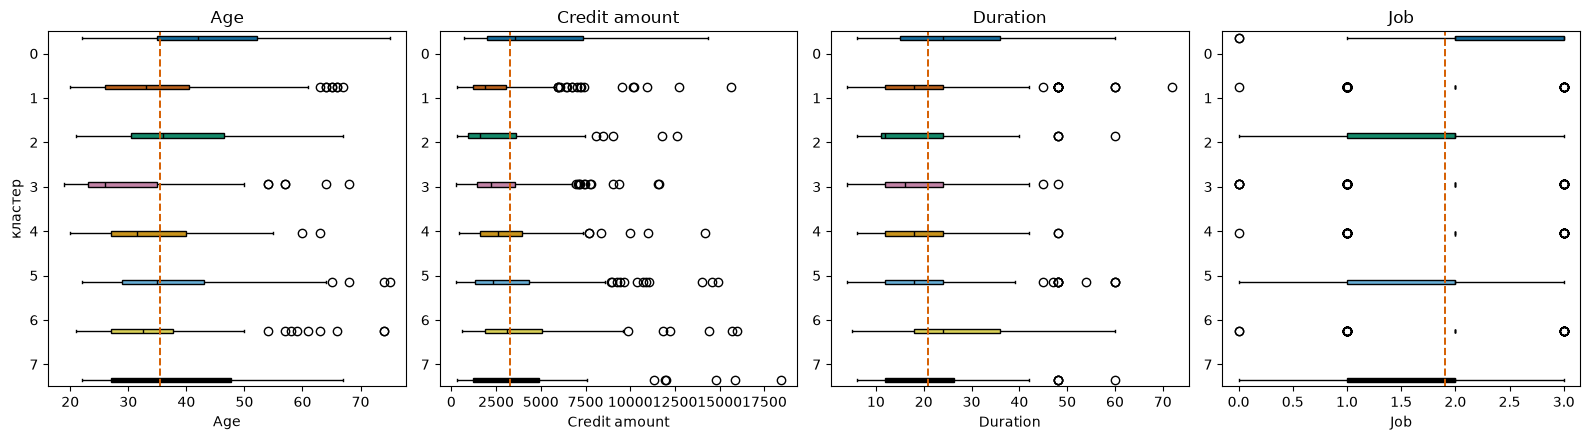

межквартильные размахи, в исходных единицах:
    Age              самый узкий    10.8, самый широкий    20.8, по всей выборке    15.0
    Credit amount    самый узкий  1850.5, самый широкий  5382.5, по всей выборке  2606.8
    Duration         самый узкий    12.0, самый широкий    21.0, по всей выборке    12.0
    Job              самый узкий     0.0, самый широкий     1.0, по всей выборке     0.0


In [41]:
tidy = df[NUMERIC].assign(cluster=pd.Categorical(CLUSTER))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, column in zip(axes, NUMERIC):
    sns.boxplot(data=tidy, x=column, y="cluster", hue="cluster", legend=False,
                palette=cluster_colors(K_ELBOW), ax=ax)
    # Пунктир — среднее по всей выборке, чтобы видеть отклонение кластеров от него.
    ax.axvline(df[column].mean(), color=COLOR_REF, linestyle="--", linewidth=1.4)
    ax.set_title(column)
    ax.set_ylabel("кластер" if column == NUMERIC[0] else "")
plt.tight_layout()
plt.show()

print("межквартильные размахи, в исходных единицах:")
for column in NUMERIC:
    q = tidy.groupby("cluster", observed=True)[column].quantile([0.25, 0.75]).unstack()
    print(f"    {column:16} самый узкий {(q[0.75] - q[0.25]).min():7.1f}, "
          f"самый широкий {(q[0.75] - q[0.25]).max():7.1f}, "
          f"по всей выборке {df[column].quantile(0.75) - df[column].quantile(0.25):7.1f}")

Boxplot'ы почти целиком накрывают друг друга и сидят на пунктире общего среднего. Межквартильные размахи внутри кластеров сопоставимы с размахом по всей выборке — то есть внутри кластера клиенты различаются почти так же сильно, как в датасете вообще.

Заметно отличается только кластер 0: бесплатное жильё, возраст выше, сумма и срок больше. У остальных отличия укладываются в разброс.

Наибольшее различие даёт `Age`, но и оно объясняет лишь 9,5% разброса. По количественным признакам интерпретировать нечего — различия между кластерами меньше различий внутри них.

### Портреты кластеров

| кластер | n | жильё | цель | портрет | bad |
|---|---|---|---|---|---|
| 0 | 84 | бесплатное | авто (65%) | старше всех (44 года), крупные и долгие займы: 4990 марок на 27 месяцев | 39% |
| 1 | 227 | своё | радио/ТВ (100%) | мелкие займы, 2540 марок — самая спокойная группа | 20% |
| 2 | 59 | смешанное | образование (100%) | средний возраст 38, займы небольшие | 39% |
| 3 | 149 | аренда | авто (42%) | самые молодые, 29,8 года | 36% |
| 4 | 122 | своё | мебель (100%) | всё около средних значений | 30% |
| 5 | 219 | своё | авто (100%) | всё около средних значений | 27% |
| 6 | 94 | своё (81%) | бизнес (100%) | крупные и долгие займы: 4110 марок на 27 месяцев | 34% |
| 7 | 46 | своё (76%) | прочее (100%) | схлопнутая редкая категория | 37% |

Колонку `bad` читать по отдельным кластерам нельзя: значимо от среднего отличается только кластер 1. Портреты складываются, но состоят они из тех двух признаков, которые кластеры и породили. Ничего сверх содержимого таблицы «жильё × цель займа» разбиение не сообщает: назвать кластер можно, а узнать из него что-то новое о клиентах — нет.

Единственное содержательное наблюдение, которого в этих двух колонках не было: цель займа связана с его размером. Бизнес и автокредиты при бесплатном жилье — около 4000–5000 марок на 27 месяцев, техника и мебель — 2500–3100 марок на 20 месяцев. Но это факт про кредитные продукты, а не про сегменты заёмщиков, и виден он прямой группировкой по `Purpose` без всякой кластеризации.

## Итоговые выводы

**Данные чистые.** 1000 заёмщиков, 9 признаков и метка `Risk`. Ни дубликатов, ни противоречивой разметки, ни настоящих пропусков: пустые ячейки в двух колонках означают "счёта нет", а не "неизвестно". Вся подготовка свелась к переводу девяти разнотипных признаков в 18 числовых колонок.

**Кластеров в данных нет.** Силуэт у всех трёх алгоритмов 0,20…0,25. Единого ответа про число кластеров тоже нет: локоть указывает на 8, силуэт KMEANS на 9, Ward на 6, DBSCAN даёт 11.

**Найденное разбиение — пересказ двух категориальных признаков.** При k = 3 кластеры KMEANS совпали с уровнями `Housing` один в один: 108 / 179 / 713. При k = 8 чистота по `Housing` 89%, по `Purpose` 88%. У DBSCAN чистота по `Housing` × `Purpose` ровно 100%.

**Интерпретировать нечего.** Разбиение объясняет 9,5% разброса возраста, 6,1% суммы займа и 5,4% срока. На boxplot-ах кластеры перекрываются почти целиком. Из восьми кластеров по доле проблемных займов значимо отличается один — займы на радио/ТВ при своём жилье, 20% против 30%. Остальные различия укладываются в доверительные интервалы.

**Почему так вышло.** Кластеры возникают там, где признаки согласованы сразу по нескольким осям. Такой согласованности в EDA не нашлось: единственная заметная связь во всём датасете — 0,625 между суммой и сроком займа. German Credit собирали для предсказания `Risk`, а не для поиска сегментов.

**Две ловушки метрики.** Лучший силуэт дважды достался вырожденному решению: у связи `average` это 954 объекта в одном кластере, у DBSCAN при `min_samples` = 36 — 849 объектов в шуме. И силуэт нельзя сравнивать между разными способами подготовки данных: 0,648 без масштабирования против 0,176 с ним, при том что первое — сортировка по сумме займа.

**Сменить кодирование не помогает.** Евклидово расстояние по one-hot колонкам действительно плохо подходит для смешанных данных: вес признака становится пропорционален числу его уровней. Придуманные для такого случая инструменты — метрика Гауэра, k-prototypes — этот артефакт снимают, каждый признак учитывается целиком независимо от кардинальности. Но задачу они не решают, и видно это из строки "все девять признаков поровну" в таблице выше: когда не побеждает никто, силуэт падает до 0,137 и кластеров не остаётся вовсе. Гауэр даёт ровно это же, только в другой записи.

**Итог.** Дело не в кодировании. Кластеризация на этих данных может либо скопировать одну из колонок, либо разрезать непрерывное облако — что именно, решают веса признаков, а не данные. Сегментов, которые существовали бы независимо от способа считать расстояние, здесь нет, и никакая метрика этого не меняет.